In [1]:
from dotenv import load_dotenv
import os
load_dotenv()
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.environ["GROQ_API_KEY"]
llm = ChatGroq(model=os.getenv("QWEN_MODEL"))

# **Custom logic to Build Human in The Loop**

In [3]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_core.tools import tool

In [4]:
@tool
def multiply(a: int, b: int) -> int:
    """This is multiply function"""
    
    return a * b

In [5]:
@tool
def search(query: str):
    "Search the wrb for a query and return the results"
    tavily = TavilySearchResults()
    result = tavily.invoke(query)
    
    return f"Result for {query} is: \n{result}"

response = search.invoke(
    {
        "query": "What is the capital of bangladesh?"
    }
)
response

'Result for What is the capital of bangladesh? is: \n[{\'title\': \'Dhaka - Wikipedia\', \'url\': \'https://en.wikipedia.org/wiki/Dhaka\', \'content\': \'Wikimedia Commons\\n   Wikinews\\n   Wikiquote\\n   Wikivoyage\\n   Wikidata item\\n\\nCoordinates: Image 423°48′15″N 90°24′55″E / 23.80417°N 90.41528°E / 23.80417; 90.41528)\\n\\nFrom Wikipedia, the free encyclopedia\\n\\nCapital and largest city of Bangladesh\\n\\nThis article is about the capital city. For the division, see Dhaka Division. For the district, see Dhaka District. For other uses, see Dhaka (disambiguation) "Dhaka (disambiguation)").\\n\\nNot to be confused with Senegal\\\'s capital city Dakar. [...] As the capital of the People\\\'s Republic of Bangladesh, Dhaka is home to numerous state and diplomatic institutions. The Bangabhaban is the official residence and workplace of the President of Bangladesh, who is the ceremonial head of state under the constitution. The National Parliament House is located in the modernist 

In [6]:
tools = [multiply, search]
tools

[StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000018C09DBC7C0>),
 StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000018C09DBCE00>)]

In [7]:
llm_with_tools = llm.bind_tools(tools, parallel_tool_calls=False)

## **To see How tools call work in the React Workflow**

In [8]:
tool_mapping = {tool.name: tool for tool in tools}
tool_mapping

{'multiply': StructuredTool(name='multiply', description='This is multiply function', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000018C09DBC7C0>),
 'search': StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000018C09DBCE00>)}

In [9]:
tool_mapping["search"]

StructuredTool(name='search', description='Search the wrb for a query and return the results', args_schema=<class 'langchain_core.utils.pydantic.search'>, func=<function search at 0x0000018C09DBCE00>)

In [10]:
tool_mapping["search"].invoke(
    {
        "query": "who is dr. yunus?"
    }
)

'Result for who is dr. yunus? is: \n[{\'title\': \'Biography of Dr. Muhammad Yunus - MSR BLOGS\', \'url\': \'https://www.msrblogs.com/students/2025/03/22/biography-of-dr-muhammad-yunus/\', \'content\': \'Dr. Muhammad Yunus: A Visionary in Social Entrepreneurship Dr. Muhammad Yunus, a Bangladeshi economist, banker, and social entrepreneur, is renowned for pioneering microfinance and microcredit—innovative financial concepts that have empowered millions of impoverished individuals worldwide. Born on June 28, 1940, in Chittagong, British India (now Bangladesh), Yunus has dedicated his life to\', \'score\': 0.86767644}, {\'title\': \'The First Nobel Prize Winner of Bangladesh - Dr. Muhammad Yunus\', \'url\': \'https://assignmentpoint.com/the-first-nobel-prize-winner-of-bangladesh-dr-muhammad-yunus/\', \'content\': \'Dr. Muhammad Yunus is the visionary and developer of the unique micro-credit concept. He is a Bangladeshi social entrepreneur, banker, economist, and civil society leader who w

In [11]:
response = llm_with_tools.invoke("what is the current weather in bangladesh.")

## **Llm route to tools call**

In [12]:
response

AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'v5qmy6p0a', 'function': {'arguments': '{"query":"current weather in Bangladesh"}', 'name': 'search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 108, 'prompt_tokens': 199, 'total_tokens': 307, 'completion_time': 0.17012183, 'prompt_time': 0.007789006, 'queue_time': 0.054559934, 'total_time': 0.177910836}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_f17c2eb555', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--2d804fcf-53a5-439f-9ac7-d4fa1af62359-0', tool_calls=[{'name': 'search', 'args': {'query': 'current weather in Bangladesh'}, 'id': 'v5qmy6p0a', 'type': 'tool_call'}], usage_metadata={'input_tokens': 199, 'output_tokens': 108, 'total_tokens': 307})

In [13]:
tool_mapping[response.tool_calls[0]["name"]].invoke(response.tool_calls[0]["args"])

'Result for current weather in Bangladesh is: \n[{\'title\': \'Met office predicts rain across country | News\', \'url\': \'https://www.bssnews.net/news/289094\', \'content\': \'DHAKA, July 4, 2025 (BSS) - The Bangladesh Meteorological Department today predicted rain or thundershowers with lightning flashes and\', \'score\': 0.8875269}, {\'title\': \'Bangladesh weather in July 2025 | Bangladesh 14 day weather\', \'url\': \'https://www.weather25.com/asia/bangladesh?page=month&month=July\', \'content\': \'| Month | Temperatures | Rainy Days | Dry Days | Snowy Days | Rainfall | Weather | More details |\\n| --- | --- | --- | --- | --- | --- | --- | --- |\\n| January | 28° / 18° | 0 | 31 | 0 | 1 mm | Perfect | Bangladesh in January |\\n| February | 32° / 19° | 1 | 28 | 0 | 7 mm | Good | Bangladesh in February |\\n| March | 36° / 23° | 2 | 29 | 0 | 26 mm | Ok | Bangladesh in March |\\n| April | 37° / 26° | 7 | 23 | 0 | 93 mm | Bad | Bangladesh in April | [...] | 20 Light rain shower 34° /27°

## **Now Build the Graph**

In [19]:
from typing import TypedDict, Sequence, Annotated
import operator
from langchain_core.messages import BaseMessage

In [20]:
class AgentState(TypedDict):
    """State for the agent."""
    messages: Annotated[Sequence[BaseMessage],operator.add]

In [21]:
def invoke_model(state:AgentState):
    pass

In [ ]:
def router(state: AgentState):
    pass

In [22]:
def invoke_tool(state:AgentState):
    pass

- eariler we were using the tool node from list of tool

- but now we have crate tool invoke(custom funtion)

- why we are doing it: as a user if we want to take a authority to which i need to give permission for execution

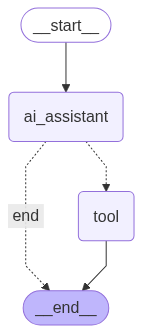

In [26]:
from langgraph.graph import StateGraph, START,END
graph=StateGraph(AgentState)

graph.add_node("ai_assistant", invoke_model)
graph.add_node("tool", invoke_tool)

graph.add_conditional_edges("ai_assistant",
                            router,
                            {
                                "tool":"tool",
                                "end":END
                            }
                            )
graph.add_edge("tool", END)

graph.set_entry_point("ai_assistant")
graph.compile()